In [1]:
# TODO: 
# 1. add the dependency structure between the tasks as an input --> support linear combination of the tasks as a feature of the system
# 2. identify the tests needed to test the code
# 3. integration with Noise model --> assess the changes 
# 4. create sample notebook
# 5. add different sampling strategies into the GPExperiment class --> discuss advantages / reasons in the demo notebook
# 6. revise whether the domain needs to be 1D or the code naturally works for N-dim domain ( I think it should) --> this should help with solving the Use Cases --> extend for 2 and 3 dimensional problem --> maybe as a new class? 

import torch
import numpy as np

from typing import List, Optional, Union, Dict, Tuple
# from .model_system import ModelSystem
# from ..space import Real
from ProcessOptimizer.model_systems import ModelSystem
from ProcessOptimizer.space import Real


class GPExperiment:
    """Base Class for 1D Gaussian Process experiment."""
    def __init__(
            self,
            lower_bound: Optional[float],
            upper_bound: Optional[float],
            tasks: Optional[int] = 1,
            signal_variance: Optional[float] = 1.5,
            lengthscale: Optional[float] = 0.75,
            seed: Optional[int] = 42,
    ):
        """
        Parameters
        ----------
        *  'lower_bound' [Optional[float]]:
            lower bound of 1D domain of Gaussian Process.
        * 'upper_bound' [Optional[float]]:
            upper bound of 1D domain of Gaussian Process.
        * 'tasks' [Optional[int]]:
            number of tasks generated from GP
        * 'seed' [Optional[int], default=42]:
            seed for numpy random number generator
        """
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.tasks = tasks
        self.signal_variance = signal_variance
        self.lengthscale = lengthscale
        self._rng = np.random.RandomState(seed)
        self.experiment = self._initiate_experiment()

    def _get_domain(self, tolist: bool = True) -> Union[torch.Tensor, List[Real]]:
        # TODO --> move this into the hash table to speed the evaluation 
        """Generates the domain of the Gaussian Process
        Parameters
        ----------
        * `gridsize` [int]:
            Number of grid points. If None, use 'grid' value from the constructor.
        * `tolist` [bool]:
            Whether to return the domain as a list. True by default to ensure compatibility with ProcessOptimizer.

        Returns
        -------
        * `domain` Union[torch.Tensor, List[Real]]:
            The domain of the Gaussian Process used by GP score.

        """
        delta, delta_grid_size = 0.01, 0.001
        basic_grid = torch.arange(self.lower_bound, self.upper_bound + delta, delta)
        gridsize = delta_grid_size / np.abs(self.lower_bound - self.upper_bound) 
        grid_domain = torch.linspace(self.lower_bound, self.upper_bound, int(gridsize))
            
        domain_join = torch.cat((basic_grid, grid_domain))
        domain,_ = torch.sort(domain_join)
        return domain.tolist() if tolist else domain

 

    def _get_exp_kernel(self, signal_variance, lengthscale):
        "RBF kernel for Gaussian Process."
        return lambda a, b: signal_variance * (
                    -0.5 * (a.reshape(-1, 1) - b.reshape(1, -1)).pow(2) / (lengthscale ** 2)).exp()

    def _sample_from_gp(self, domain, kernel) -> torch.Tensor:
        """
         Sample trajectories of the Gaussian Process.
         The total number of trajectories is equal to number of tasks.
        """
        K = kernel(domain, domain)
        # sample from N(0, K):
        # L: LL' = K
        # f = L @ z, z ~ N(0, I)
        d, V = torch.linalg.eigh(K)  # computes the eigenvalue decomposition, d - eig values, V - eigen vectors
        L = d.clamp_min(0.0).sqrt() * V
        f = L @ torch.randn(L.shape[0], self.tasks)
        return f.squeeze()

    def _initiate_experiment(self) -> Dict:
        domain = self._get_domain(False)
        task_values = self._sample_from_gp(domain, kernel=self._get_exp_kernel(self.signal_variance, self.lengthscale))
        experiment = {'domain': domain, 'f_values': task_values}

        return experiment

    def get_experiment(self):
          return [self.experiment['domain'].tolist(),
                  self.experiment['f_values'].tolist()]
    
    @property 
    def domain(self):
        return self.experiment['domain'].tolist()
    
    @property 
    def f_values(self):
        return  self.experiment['f_values'].tolist()

    def score(self, x: Optional[float]) -> float:
        toll = 2.0e-05
        closest_candidate = torch.min(torch.abs(self.experiment['domain']- x))
        if closest_candidate <= toll:
            idx = torch.argmin(torch.abs(self.experiment['domain'] - x))
            return self.experiment['f_values'][idx].tolist()
        else:
            l, u = self._find_closest_pair_idx(x)
            weight = (x - self.experiment['domain'][l]) / (self.experiment['domain'][u] - self.experiment['domain'][l])
            score = torch.lerp(self.experiment['f_values'][l], self.experiment['f_values'][u], weight)
            return score.tolist()
         
    def _find_closest_pair_idx(self, x) -> Tuple[int, int]:
        closest_candidate_idx = torch.argmin(torch.abs(self.experiment['domain']- x))
        closest_candidate = self.experiment['domain'][closest_candidate_idx]
        
        is_smaller = closest_candidate < x
        is_lower_boundary = closest_candidate == lower_bound
        
        if is_lower_boundary or is_smaller: 
            return (closest_candidate_idx, closest_candidate_idx+1) 
        else: 
            return (closest_candidate_idx-1, closest_candidate_idx)

    def get_sample(self, size, noise_scale=0.1):
        indices = np.random.choice(range(self.experiment['domain'].shape[0]), size, replace=False)
        x = torch.Tensor(self.experiment['domain'][indices])
        y = torch.Tensor( self.experiment['f_values'][indices,:]) + noise_scale * torch.randn(
            self.experiment['f_values'][indices,:].size())  # sigma * N(0, 1) + m = N(m, sigma^2)
        return indices, x, y

    @property
    def max(self):
      if self.tasks == 1: 
        return torch.max(self.experiment['f_values']).item()
      else:
        return torch.max(self.experiment['f_values'].T, 1)[0].tolist()
    @property
    def min(self):
      if self.tasks == 1: 
        return torch.min(self.experiment['f_values']).item()
      else:
        return torch.min(self.experiment['f_values'].T, 1)[0].tolist()

def create_gp_experiment(
    lower_bound: Optional[float],
    upper_bound: Optional[float],
    tasks: Optional[int] = 1,
    signal_variance: Optional[float] = 1.5,
    lengthscale: Optional[float] = 0.75,
    grid: Optional[int] = 200, noise: bool = True) -> ModelSystem:
    gp_experiment = GPExperiment(lower_bound, upper_bound, tasks, signal_variance, lengthscale)
    return ModelSystem(
        gp_experiment.score,
        [Real(lower_bound, upper_bound, name='domain')],
        noise_model=None,
        true_max=gp_experiment.max,
        true_min=gp_experiment.min)

**GP Experiment Model System** samples from the Gausian Process with RGB kernel and simulates 'the true unknown system'. Assume that the data from the lab experiments come from the distribution of Gaussian Process. The realised trajectory corresponds to one expriment. Even if the data from different laboratory settings differ, in this simlified setup we assume that the generative model for the lab experiments is driven by Gaussian distribution over given domain.

*  'lower_bound' [Optional[float]]:
    lower bound of 1D domain of Gaussian Process.
*  'upper_bound' [Optional[float]]:
    upper bound of 1D domain of Gaussian Process.
*  'tasks' [Optional[int]]:
    number of tasks generated from GP
* 'signal_variance': Optional[float]
* 'lengthscale': Optional[float]
* 'seed' [Optional[int], default=42]:
    seed for numpy random number generator
     

# Compatibility with Process Optimiser 

In [1]:
from ProcessOptimizer.model_systems import gaussian_process_benchmark as gp_benchmark
from ProcessOptimizer import Optimizer
from ProcessOptimizer.learning import GaussianProcessRegressor
from ProcessOptimizer.learning.gaussian_process import kernels

from ProcessOptimizer.learning import ExtraTreesRegressor
from ProcessOptimizer import Optimizer
lower_bound = -1.5
upper_bound = 1.5

opt = Optimizer([(lower_bound, upper_bound)], 
            base_estimator=GaussianProcessRegressor(
            kernel=kernels.ConstantKernel(constant_value=1.8)*kernels.RBF(length_scale=0.3),
            normalize_y=True,
            noise="gaussian",
            n_restarts_optimizer=4,
        )
, acq_optimizer="sampling")
gp1 = gp_benchmark.GPExperiment(lower_bound, upper_bound)
print('min: %s'%(gp1.min))

path = {}

for idx_ in range(50):
    next = opt.ask()
    f_val = gp1.score(next[0])
    opt.tell(next, f_val)
    path[idx_] = [next[0], f_val]

min: -1.5765904188156128


In [3]:
path

{0: [0.15000000000000013, 0.5780378580093384],
 1: [0.4500000000000002, 0.2595787048339844],
 2: [-1.35, 0.16759994626045227],
 3: [0.75, 0.17285828292369843],
 4: [-0.4500000000000002, 1.660865306854248],
 5: [-0.75, 1.6840472221374512],
 6: [-0.1499999999999999, 1.1442217826843262],
 7: [1.3499999999999996, 0.25281816720962524],
 8: [-1.05, 1.1038845777511597],
 9: [1.0499999999999998, 0.20075304806232452],
 10: [-1.4996754106368413, -0.3260352611541748],
 11: [-1.499739911128478, -0.32622888684272766],
 12: [-1.499781582167445, -0.32635417580604553],
 13: [-1.4999147922128855, -0.3267539441585541],
 14: [-1.4995456019659514, -0.3256455361843109],
 15: [-1.4999553223889126, -0.32687562704086304],
 16: [-1.499232038839207, -0.32470425963401794],
 17: [-1.4993929154861152, -0.3251870572566986],
 18: [-1.4997536829742273, -0.3262704014778137],
 19: [-1.4999665179746828, -0.32690924406051636],
 20: [-1.4995251078955747, -0.32558396458625793],
 21: [-1.4988022738697893, -0.323414057493209

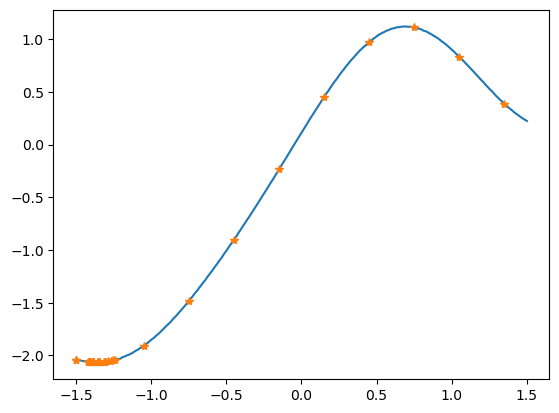

In [4]:
import matplotlib.pyplot as plt
plt.plot(gp1.domain, gp1.f_values);
plt.plot([val[0] for _, val in path.items()], [val[1] for _, val in path.items()], '*')

nts from the 4 experiments with features taking values on the domain [-1.5, 1.5]. The underlying generative process of these data is Gaussian process with RBF with lengthscale 0.5 and signal variance 1.5.

In [5]:
gp1.f_values[150]

0.11321578174829483

In [6]:
gp2 = gp_benchmark.GPExperiment(-1.5, 1.5, 4, 1.5, 0.5)

idx, train_x, train_y = gp2.get_sample(10)

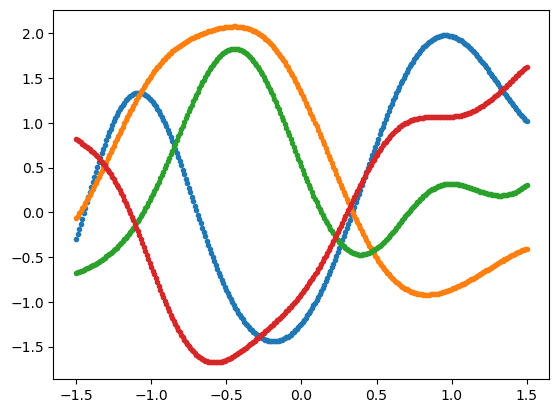

In [7]:
from matplotlib import pyplot as plt

plt.plot(gp2.domain, gp2.f_values, '.');

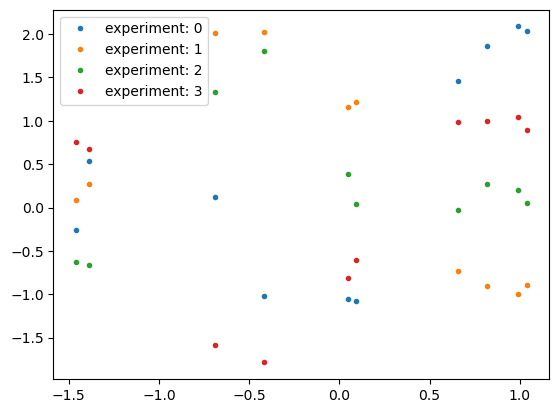

In [8]:
from matplotlib import pyplot as plt

for idx_ in range(train_y.shape[1]):
  plt.plot(train_x, train_y[:, idx_], '.', label='experiment: %s'%(idx_));

plt.legend();

In [9]:
train_y[...,0]

tensor([-0.2640, -1.0148,  2.0411,  0.5397, -1.0826,  1.4574, -1.0519,  1.8583,
         2.0881,  0.1234])

In [10]:
train_x.reshape(-1, 1).shape

torch.Size([10, 1])

In [11]:
from ProcessOptimizer.learning import GaussianProcessRegressor
from ProcessOptimizer.learning.gaussian_process import kernels

kernel_ = kernels.ConstantKernel(constant_value=1.8)*kernels.RBF(length_scale=0.3)
gp = GaussianProcessRegressor(kernel=kernel_).fit(train_x.reshape(-1, 1), train_y[...,0])

In [12]:
gp.get_params()

{'alpha': 1e-10,
 'copy_X_train': True,
 'kernel__k1': 1.34**2,
 'kernel__k2': RBF(length_scale=0.3),
 'kernel__k1__constant_value': 1.8,
 'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
 'kernel__k2__length_scale': 0.3,
 'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
 'kernel': 1.34**2 * RBF(length_scale=0.3),
 'n_restarts_optimizer': 0,
 'noise': None,
 'noise_level_bounds': (1e-05, 100000.0),
 'normalize_y': False,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': None}

In [13]:
params = {
     'alpha': 1e-10,
     'copy_X_train': True,
     'kernel__k1': 1.34**2,
     'kernel__k2': kernels.RBF(length_scale=0.4),
     'kernel__k1__constant_value': 1.8,
     'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
     'kernel__k2__length_scale': 0.3,
     'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
     'kernel': 1.34**2 * kernels.RBF(length_scale=0.3),
     'n_restarts_optimizer': 0,
     'noise': None,
     'noise_level_bounds': (1e-05, 100000.0),
     'normalize_y': False,
     'optimizer': 'fmin_l_bfgs_b',
     'random_state': None
}

In [14]:
gp.set_params(**params)

GaussianProcessRegressor(kernel=1.7956000000000003 * RBF(length_scale=0.4))

In [15]:
import ProcessOptimizer as op

In [16]:
from ProcessOptimizer.space import Categorical

# Task Control Parameter and Process Optimizer

In [17]:
from ProcessOptimizer.space import Categorical, Task, Dimension, Real, Integer, Space, check_dimension
from ProcessOptimizer import Optimizer
lower_bound = -1.5
upper_bound = 1.5
active_task_ = 3

In [18]:
task_dim = Task([0, 1, 2, 3], active_task=active_task_ )
task_space = Space([[lower_bound, upper_bound], task_dim])
print(f"Task space:\n{task_space}\n")
print(task_dim.__dict__)

Task space:
Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=3, prior=None)])

{'tasks': (0, 1, 2, 3), '_name': None, 'transform_': 'onehot', 'transformer': <ProcessOptimizer.space.transformers.CategoricalEncoder object at 0x3040bb620>, 'prior_': array([0.25, 0.25, 0.25, 0.25]), 'active_task': 3, 'prior_active_task_': array([0., 0., 0., 1.])}


In [19]:
task_space 

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=3, prior=None)])

In [20]:
task_space.lhs(10, active_task=True)

[[0.15000000000000013, 3],
 [0.4500000000000002, 3],
 [-1.35, 3],
 [0.75, 3],
 [-0.4500000000000002, 3],
 [-0.75, 3],
 [-0.1499999999999999, 3],
 [1.3499999999999996, 3],
 [-1.05, 3],
 [1.0499999999999998, 3]]

In [21]:
Space([[-1.5, 1.5], [0, 1, 2, 3, {3}]]).lhs(10, active_task=True)

[[0.15000000000000013, 3],
 [0.4500000000000002, 3],
 [-1.35, 3],
 [0.75, 3],
 [-0.4500000000000002, 3],
 [-0.75, 3],
 [-0.1499999999999999, 3],
 [1.3499999999999996, 3],
 [-1.05, 3],
 [1.0499999999999998, 3]]

In [22]:
opt2 = Optimizer(
    dimensions=task_space,
    base_estimator="GP", 
    n_initial_points=5,
    acq_func='EI',
    acq_optimizer="sampling",
    n_objectives=1, 
    active_task=True)
print(task_space)
gp2 = gp_benchmark.GPExperiment(-1.5, 1.5, 4, 1.5, 0.5)
print('min: %s'%(gp2.min[active_task_]))

path = {}

for idx_ in range(25):
    next = opt2.ask()
    f_val = gp2.score(next[0])
    opt2.tell(next, f_val[active_task_])
    path[idx_] = [next, f_val]
    print('%s: %s'%(idx_, path[idx_]))

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=3, prior=None)])
min: -2.4313197135925293
0: [[1.2000000000000002, 3], [-0.7693737745285034, 2.5316715240478516, 1.487592339515686, 0.46340659260749817]]
1: [[0.0, 3], [-1.006856083869934, -0.6866995692253113, 0.06087929755449295, -1.5564141273498535]]
2: [[0.5999999999999996, 3], [-2.06020188331604, -0.584778368473053, 0.9341720342636108, 2.3836820125579834]]
3: [[-0.6000000000000001, 3], [-0.1416848748922348, -1.3801993131637573, 0.9902064800262451, -1.6578483581542969]]
4: [[-1.2, 3], [-0.5073794722557068, -2.8416907787323, -0.048766035586595535, 0.4655344486236572]]
5: [[-0.35031998149377896, 3], [-0.3775339424610138, -0.8766558170318604, 0.7159876823425293, -2.3735854625701904]]
6: [[-0.23799253037824952, 3], [-0.49569615721702576, -0.7775205373764038, 0.4435157775878906, -2.417570114135742]]
7: [[-0.2787018524961056, 3], [-0.4467458426952362, -0.8088309168815613, 0.

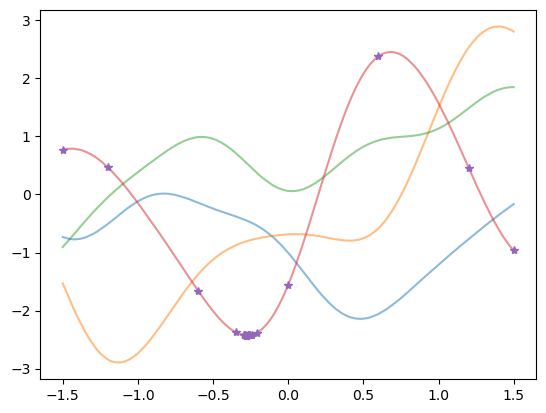

In [23]:
import matplotlib.pyplot as plt
plt.plot(gp2.domain, gp2.f_values, alpha=0.5);
plt.plot([val[0][0] for _, val in path.items()], [val[1][active_task_] for _, val in path.items()], '*');

In [24]:
opt3 = Optimizer(
    dimensions=task_space,
    base_estimator="GP", 
    n_initial_points=5,
    acq_func='EI',
    acq_optimizer="sampling",
    n_objectives=1)
print(task_space)
gp3 = gp_benchmark.GPExperiment(-1.5, 1.5, 4, 1.5, 0.5)
print('min: %s'%(gp3.min[active_task_]))

path = {}

for idx_ in range(25):
    next = opt3.ask()
    f_val = gp3.score(next[0])
    opt3.tell(next, f_val[active_task_])
    path[idx_] = [next, f_val]
    print('%s: %s'%(idx_, path[idx_]))

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=3, prior=None)])
min: -1.6693788766860962
0: [[1.2000000000000002, 2], [-1.1988319158554077, 1.1620570421218872, -0.15778596699237823, 1.6554501056671143]]
1: [[0.0, 0], [-0.6427520513534546, 0.8237596154212952, 2.6468186378479004, -0.5740034580230713]]
2: [[0.5999999999999996, 1], [-1.3981819152832031, 0.19495633244514465, -0.3014678359031677, 0.17248882353305817]]
3: [[-0.6000000000000001, 2], [0.26676270365715027, 1.5439002513885498, 1.9862948656082153, -0.9770115613937378]]
4: [[-1.2, 3], [-0.7789276838302612, 1.551992654800415, 0.7621275782585144, -1.52543306350708]]
5: [[-0.7655880667212671, 3], [0.12926353514194489, 2.016772747039795, 1.576825499534607, -1.1612504720687866]]
6: [[-1.4990315820642066, 2], [-0.9114868640899658, -0.3490404188632965, -0.25251883268356323, -1.6692596673965454]]
7: [[-1.499999262912581, 0], [-0.9108873605728149, -0.3550543487071991, -0.2

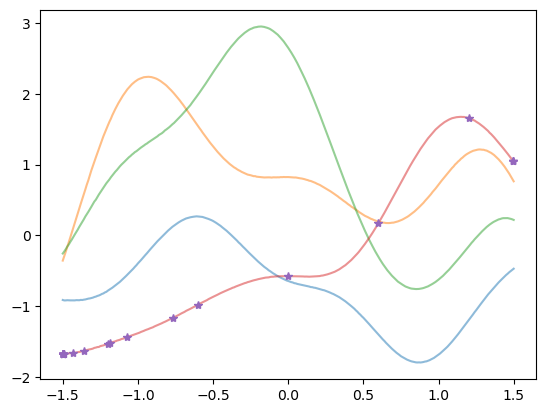

In [25]:
import matplotlib.pyplot as plt
plt.plot(gp3.domain, gp3.f_values, alpha=0.5);
plt.plot([val[0][0] for _, val in path.items()], [val[1][active_task_] for _, val in path.items()], '*');